# Your first forecast

This page takes a monthly time series from raw data to a validated forecast in a few calls, with no LLM, no API key and no configuration. Along the way you will:

+ evaluate the model on the last year of data before trusting it,
+ read the metrics, the decisions behind them and the script that produced them,
+ retrain on all the history and forecast the next twelve months with a prediction interval.

Every step runs a real **skforecast** pipeline on your machine, chosen by transparent rules. If the package is not installed yet, see [Installation](how-to-install.html).

<div role="note"
     style="background: rgba(0,184,212,.08); border-left: 6px solid #00b8d4; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">
  <p style="display: flex; align-items: center; font-size: 1rem; color: #00b8d4; margin: 0 0 6px 0; font-weight: 600;">
    <span style="margin-right: 6px; font-size: 1.125em;">✏️</span>
    <strong style="font-size: 18px;">New to forecasting?</strong>
  </p>

  <p>
skforecast's <a href="https://skforecast.org/latest/introduction-forecasting/introduction-forecasting">Introduction to forecasting</a> covers the machine learning fundamentals (lags, recursive and direct multi-step prediction) this page builds on.
  </p>
</div>

## Load the data

The series is the monthly expenditure on corticosteroid drugs in the Australian health system between July 1991 and June 2008 (204 months). Any pandas `DataFrame` with a value column and a date column works; `forecast()` also accepts the path to a CSV file.

In [1]:
# Libraries
# ==============================================================================
import pandas as pd
from skforecast_ai import ForecastingAssistant

# Download data
# ==============================================================================
url = (
    "https://raw.githubusercontent.com/skforecast/skforecast-datasets/"
    "refs/heads/main/data/h2o.csv"
)
data = pd.read_csv(url, sep=",", header=0, names=["y", "date"])
data.head()

,y,date
0,0.429795,1991-07-01
1,0.400906,1991-08-01
2,0.432159,1991-09-01
3,0.492543,1991-10-01
4,0.502369,1991-11-01


The frame has two columns: `y`, the value to forecast, and `date`, the first day of each month. There is no need to parse the dates or set the frequency: the assistant infers both.

## Create the assistant

With no arguments, `ForecastingAssistant` runs in **deterministic mode**: every decision comes from rules, and the same data always gives the same forecast.

In [2]:
# Assistant without LLM
# ==============================================================================
assistant = ForecastingAssistant()

## Evaluate the model

Before forecasting the future, measure how well the model would have done on data it has not seen. Passing `test_size=12` holds out the last twelve months: the assistant trains on the months before them, predicts the held-out year and compares the predictions with the actual values.

In [3]:
# Evaluate on the last 12 months
# ==============================================================================
result = assistant.forecast(
             data        = data,
             target      = "y",
             date_column = "date",
             steps       = 12,
             test_size   = 12,
         )
result.metrics

,series,MAE,MSE,MASE,MAPE
0,y,0.078442,0.008933,0.802828,0.088608


A MASE (mean absolute scaled error) below 1 means the model makes smaller errors than a naive forecast that repeats the previous value; here it is about 20% better. The MAPE says the monthly predictions are off by about 9% on average. One year is a single test, though: to repeat the evaluation over several years, use [backtesting](../user-guides/agentic-forecasting-step-by-step.html).

`test_size` accepts three forms:

| Value | Meaning |
|:------|:--------|
| `int`, for example `12` | The last *n* observations form the test set. |
| `float` in (0, 1), for example `0.2` | The last fraction of the observations forms the test set. |
| date string or `Timestamp`, for example `"2007-07-01"` | The first date of the test set. |

Whatever the form, the test set must hold exactly `steps` observations, since one forecast of `steps` values is compared with it; otherwise `forecast()` raises a `ValueError`. To evaluate over a longer period, use backtesting.

## Explore the result

`forecast()` returns a `ForecastResult`, which bundles everything the assistant used and produced:

| Attribute | Content |
|:----------|:--------|
| `predictions` | The predicted values, plus the interval bounds when an interval is requested. |
| `metrics` | MAE, MSE, MASE and MAPE, one row per series. `None` when there is nothing to compare against. |
| `profile` | What the data inspection found: frequency, date range, significant lags, and the choice of forecaster and estimator. |
| `plan` | The configuration that ran: forecaster, estimator, lags, window features, calendar features and preprocessing. |
| `code` | The standalone skforecast script that produced the predictions. |

Displayed in a notebook, the result renders a summary of all of them.

In [4]:
# Full result
# ==============================================================================
result

      Dataset Profile      
┏━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Property       ┃ Value  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Format         │ single │
├────────────────┼────────┤
│ Series         │ 1      │
├────────────────┼────────┤
│ Observations   │ 204    │
├────────────────┼────────┤
│ Frequency      │ MS     │
├────────────────┼────────┤
│ Target         │ y      │
├────────────────┼────────┤
│ Exog columns   │ None   │
├────────────────┼────────┤
│ Missing values │ None   │
└────────────────┴────────┘

                                      Recommendation                                      
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                                  │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                            │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation,   │
│                       │ ForecasterStats                                                │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Estimator             │ Ridge                                                          │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ Ridge, RandomForestRegressor, LGBMRegressor                    │
└───────────────────────┴────────────────────────────────────────────────────────────────┘

╭───────────────────────────────── Profile Explanation ──────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 204         │
│  observations, 'MS' frequency. Alternative forecasters: ['ForecasterDirect',           │
│  'ForecasterFoundation', 'ForecasterStats']. Estimator: Ridge. A linear model is       │
│  preferred because the dataset is small (204 observations < 250); gradient boosting    │
│  is offered as an alternative once more data is available. Alternative estimators:     │
│  ['RandomForestRegressor', 'LGBMRegressor'].                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ Ridge                                                              │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 12                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ MS                                                                 │
├───────────────────┼───────────────

Each decision in the plan comes with the rule that made it. The lags, for example, are the significant ones of the partial autocorrelation: the previous month and the months around the yearly cycle.

In [5]:
# Decisions of the plan
# ==============================================================================
print(result.plan.explanation)

Plan: ForecasterRecursive + Ridge. Lags: [1, 9, 10, 11, 12, 13, 14]. Window features: ['mean(window=3)', 'std(window=3)', 'mean(window=12)', 'mean(window=36)']. Calendar features: ['month', 'quarter'] (cyclical encoding). NaN rows kept (NaN-tolerant estimator). MAE is interpretable, robust to outliers, and works at any scale.


### The script that ran

`result.code` is not a reconstruction of what happened: it is the exact script the assistant executed to produce `result.predictions`, preceded by the lines that load the data from `data.csv`.

In [6]:
# Standalone skforecast script
# ==============================================================================
result.show_code()

<div role="note"
    style="background: rgba(0,191,191,.08); border-left: 6px solid #00bfa5;
        border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#00bfa5;
        margin:0 0 6px 0; font-weight:600;">
<span style="margin-right:6px; font-size:18px;">💡</span>
<strong style="margin-right:6px; font-size:18px;">Take the script with you</strong>
</p>

<p>
Save the script as a <code>.py</code> file next to your data and it runs on its own, with skforecast and scikit-learn installed and no dependency on skforecast-ai. To get the script without running anything, use <code>assistant.forecast_code()</code> with the same arguments.
</p>

</div>

## Forecast the future

Once the evaluation is convincing, drop `test_size`. The assistant retrains on the whole history and predicts the next twelve months, July 2008 to June 2009. `interval=[0.1, 0.9]` adds the 10% and 90% quantiles, an 80% prediction interval around each point.

In [7]:
# Forecast the next 12 months with an 80% interval
# ==============================================================================
forecast = assistant.forecast(
               data        = data,
               target      = "y",
               date_column = "date",
               steps       = 12,
               interval    = [0.1, 0.9],
           )
forecast.predictions

,pred,lower_bound,upper_bound
2008-07-01,0.977558,0.869480,1.045279
2008-08-01,1.070100,1.031488,1.173760
2008-09-01,1.092169,1.047934,1.224267
2008-10-01,1.115464,1.055412,1.197483
2008-11-01,1.170256,1.061210,1.216890
2008-12-01,1.189969,1.082191,1.257953
2009-01-01,1.204903,1.079588,1.257518
2009-02-01,0.810544,0.731936,0.883607
2009-03-01,0.680626,0.600400,0.738243
2009-04-01,0.852268,0.779507,0.928484


There are no metrics this time (`forecast.metrics` is `None`): the future has no actual values to compare against. If the data had exogenous variables, their future values would go in the `exog` argument.

The plot puts both runs together: the evaluation on the last year of history and the forecast of the next one.

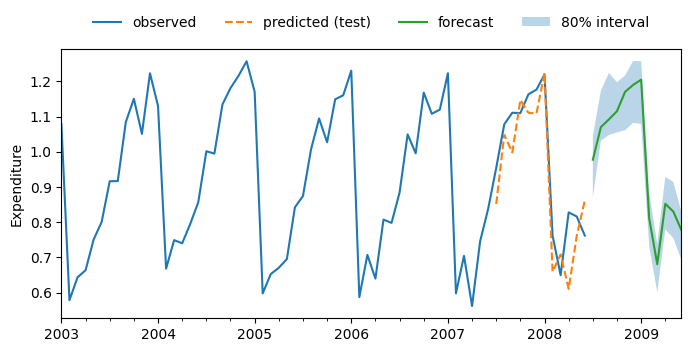

In [8]:
# Plot the evaluation and the forecast
# ==============================================================================
import matplotlib.pyplot as plt

history = data.set_index(pd.to_datetime(data["date"]))["y"]
test_predictions = result.predictions["pred"]
future = forecast.predictions

fig, ax = plt.subplots(figsize=(8, 3.5))
history.loc["2003":].plot(ax=ax, label="observed")
test_predictions.plot(ax=ax, linestyle="--", label="predicted (test)")
future["pred"].plot(ax=ax, label="forecast")
ax.fill_between(
    future.index,
    future["lower_bound"],
    future["upper_bound"],
    alpha = 0.3,
    label = "80% interval",
)
ax.set_xlabel("")
ax.set_ylabel("Expenditure")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.17), ncols=4, frameon=False)
plt.show()

## Under the hood

`forecast()` is a shortcut for four rule-based steps. Each one is a public method that returns an object you can inspect or change before passing it to the next, and none of them involves an LLM.

[Ask the assistant](ask-the-assistant.html) shows in an animation where the optional LLM fits in these steps: what reaches it, and how its suggestions are validated before they enter the plan.

In code, the four steps are:

In [9]:
# The same forecast, step by step
# ==============================================================================
profile = assistant.profile(data=data, target="y", date_column="date")    # inspect the data
plan    = assistant.plan(profile=profile, steps=12)                        # choose lags and features
script  = assistant.forecast_code(data=data, profile=profile, plan=plan)   # render the script
result  = assistant.forecast(data=data, profile=profile, plan=plan)        # run that script

result.code == script.code

True

The [step by step guide](../user-guides/agentic-forecasting-step-by-step.html) shows every object on an hourly dataset, together with `refine_plan()`, backtesting and `compare()`.

## Next steps

+ **[Ask the assistant](ask-the-assistant.html)**: connect an LLM to explain this forecast, add your domain knowledge to the plan or describe how the model will be deployed.
+ **[Agentic forecasting](../user-guides/agentic-forecasting.html)**: a complete example on hourly data with exogenous variables, backtesting and model comparison.
+ **[Using the CLI](../user-guides/cli-usage.html)**: the same pipeline from the terminal.